# PII / PHI Detection & Redaction

**Context:** Shift-log narratives are written quickly under pressure.  Staff
sometimes include client full names, phone numbers, addresses, or specific
dates that constitute *Personally Identifiable Information* (PII) — and in a
healthcare-adjacent setting, *Protected Health Information* (PHI) under
HIPAA-adjacent best practices.

Automatically detecting and redacting PII before a narrative leaves the
system (e.g. before a CSV export or an LLM call) is a critical
responsible-AI safeguard.

**Two-layer approach:**
1. **spaCy NER** — a pre-trained Named Entity Recognition model detects
   linguistic entities: `PERSON`, `DATE`, `ORG`, `GPE` (geopolitical location).
2. **Regex patterns** — rule-based matching for structured PII that NER often
   misses: phone numbers, street addresses, emails, SSNs.

**Skills demonstrated:** NLP pipeline construction, NER, regex, precision/recall
evaluation against ground-truth labels, responsible AI / privacy engineering.


In [1]:
import warnings, os, re
warnings.filterwarnings("ignore")
%matplotlib inline

import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120})

DATA_PATH    = "data/shift_log_synthetic.csv"
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

nlp = spacy.load("en_core_web_sm")
print(f"spaCy {spacy.__version__}  |  model: en_core_web_sm")

df = pd.read_csv(DATA_PATH)
n_pii = df["pii_terms"].notna().sum() - (df["pii_terms"] == "").sum()
print(f"Dataset: {df.shape[0]:,} rows  |  rows with ground-truth PII: {n_pii}")
df[["narrative","pii_terms"]].dropna().head(4)

spaCy 3.8.14  |  model: en_core_web_sm
Dataset: 900 rows  |  rows with ground-truth PII: 192


,narrative,pii_terms
1,An attorney requested a meeting regarding L.S....,480-555-8365
3,Client H.J. was found in an unauthorized area ...,Dr. Patel
4,Exterior door near the dayroom found propped o...,"April 04, 2026"
10,M.K. was withdrawn today and skipped CBT group...,Maria Gonzalez|2249 4th St


## 1  PII detector — combining NER + regex

In [2]:
# ── Regex patterns ──────────────────────────────────────────────────────────
PHONE_RE = re.compile(
    r'\b(?:\d{3}[-.\s]\d{3}[-.\s]\d{4}|\(\d{3}\)\s*\d{3}[-.\s]\d{4})\b'
)
EMAIL_RE = re.compile(r'[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}')
ADDR_RE  = re.compile(
    r'\b\d{1,5}\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*'
    r'\s+(?:Ave|Avenue|St|Street|Rd|Road|Blvd|Boulevard|'
    r'Dr|Drive|Ln|Lane|Way|Ct|Court|Pl|Place)\b'
)
SSN_RE  = re.compile(r'\b\d{3}-\d{2}-\d{4}\b')

# spaCy NER entity types we treat as PII in this domain
PII_ENTS = {"PERSON", "DATE", "GPE", "LOC"}


def detect_pii(text):
    # Returns list of {text, label, start, end} for each PII span found
    spans = []
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in PII_ENTS:
            spans.append({"text": ent.text, "label": ent.label_,
                          "start": ent.start_char, "end": ent.end_char})
    for pat, label in [(PHONE_RE,"PHONE"),(EMAIL_RE,"EMAIL"),
                       (ADDR_RE,"ADDRESS"),(SSN_RE,"SSN")]:
        for m in pat.finditer(text):
            spans.append({"text": m.group(), "label": label,
                          "start": m.start(), "end": m.end()})
    # Sort and deduplicate overlapping spans (keep the longer one)
    spans.sort(key=lambda x: (x["start"], -(x["end"]-x["start"])))
    deduped, last_end = [], -1
    for s in spans:
        if s["start"] >= last_end:
            deduped.append(s)
            last_end = s["end"]
    return deduped


def redact(text):
    # Replace each PII span with [LABEL]
    spans = detect_pii(text)
    out, pos = [], 0
    for s in spans:
        out.append(text[pos:s["start"]])
        out.append(f"[{s['label']}]")
        pos = s["end"]
    out.append(text[pos:])
    return "".join(out)


# Quick demo
samples = [
    "Spoke with Linda Carter about the situation. Contact number on file is 480-555-6536.",
    "Client listed address is 4521 Maple Ave. Follow-up scheduled for March 15, 2026.",
    "Officer Daniels arrived to meet with client J.M. Verified credentials.",
]
for s in samples:
    print("BEFORE:", s)
    print("AFTER :", redact(s))
    print()

BEFORE: Spoke with Linda Carter about the situation. Contact number on file is 480-555-6536.
AFTER : Spoke with [PERSON] about the situation. Contact number on file is [PHONE].

BEFORE: Client listed address is 4521 Maple Ave. Follow-up scheduled for March 15, 2026.
AFTER : Client listed address is [ADDRESS]. Follow-up scheduled for [DATE].

BEFORE: Officer Daniels arrived to meet with client J.M. Verified credentials.
AFTER : Officer [PERSON] arrived to meet with client [PERSON] credentials.



## 2  Evaluation against ground-truth PII labels

In [3]:
pii_df = df[df["pii_terms"].notna() & (df["pii_terms"] != "")].copy()
print(f"Rows with ground-truth PII: {len(pii_df)}")

tp = fp = fn = 0
missed_examples, fp_examples = [], []

for _, row in pii_df.iterrows():
    gt_terms  = set(t.strip().lower() for t in row["pii_terms"].split("|") if t.strip())
    detected  = [s["text"].lower() for s in detect_pii(row["narrative"])]
    for gt in gt_terms:
        if any(gt in d or d in gt for d in detected):
            tp += 1
        else:
            fn += 1
            missed_examples.append({"missed": gt, "narrative": row["narrative"][:90]})
    for d in detected:
        if not any(gt in d or d in gt for gt in gt_terms):
            fp += 1
            fp_examples.append({"detected": d})

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nTP={tp}  FP={fp}  FN={fn}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1        : {f1:.3f}")

Rows with ground-truth PII: 192



TP=280  FP=114  FN=15
Precision : 0.711
Recall    : 0.949
F1        : 0.813


## 3  What gets missed and what are false positives?

In [4]:
fn_df = pd.DataFrame(missed_examples[:6])
if not fn_df.empty:
    print("=== Missed PII (False Negatives) ===")
    print(fn_df.to_string(index=False))
    print()

fp_df = pd.DataFrame(fp_examples[:8])
if not fp_df.empty:
    print("=== False Positives — detected but not ground-truth PII ===")
    print(fp_df.to_string(index=False))
    print()
print("Analysis: spaCy DATE captures time phrases ('the 06:30 shift') that")
print("aren't personally identifying. Regex ADDRESS occasionally matches room")
print("numbers or zip codes when the pattern overlaps.")

=== Missed PII (False Negatives) ===
         missed                                                                                  narrative
    5276 4th st Client G. left the property without authorization and did not return for the 3:20 AM check
   sandra mills Administered scheduled medications at 2:30 AM; all counts correct and the MAR was signed. 
    9077 4th st W.N. showing escalating withdrawal symptoms overnight. Nurse notified; placed on closer mo
officer daniels Clients reporting the swamp cooler in Room 123 is not working. Contacted maintenance; temp
officer daniels Client P. reported a phone charger missing from their room. Took a statement, searched com
   sandra mills K. showing escalating withdrawal symptoms overnight. Spoke with Sandra Mills about the sit

=== False Positives — detected but not ground-truth PII ===
   detected
client h.j.
       m.k.
      today
       s.s.
     client
     client
     client
     client

Analysis: spaCy DATE captures time phrases (

## 4  Batch redaction across all narratives

Narratives flagged as containing PII: 446 / 900 (49.6%)
Mean PII items per flagged narrative : 1.5

Entity type breakdown:
  PERSON    : 282
  GPE       : 136
  DATE      : 114
  PHONE     : 78
  ADDRESS   : 58


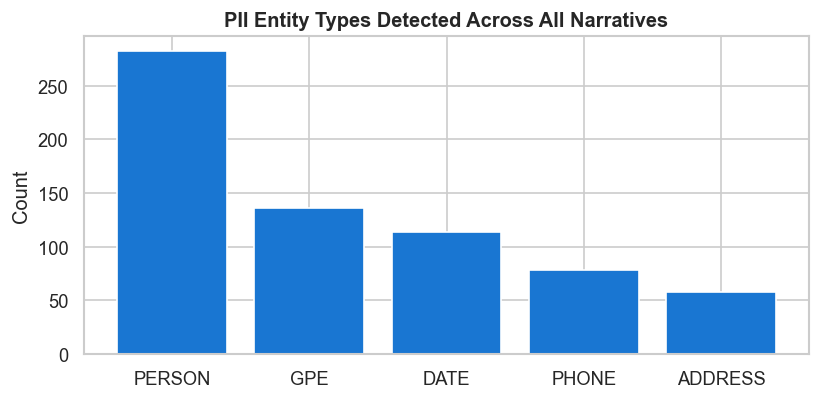

In [5]:
df["redacted"]     = df["narrative"].apply(redact)
df["pii_detected"] = df["narrative"].apply(lambda t: len(detect_pii(t)) > 0)
df["pii_count"]    = df["narrative"].apply(lambda t: len(detect_pii(t)))
df["entity_types"] = df["narrative"].apply(lambda t: [s["label"] for s in detect_pii(t)])

flagged = df["pii_detected"].sum()
print(f"Narratives flagged as containing PII: {flagged} / {len(df)} ({flagged/len(df):.1%})")
print(f"Mean PII items per flagged narrative : {df.loc[df.pii_detected,'pii_count'].mean():.1f}")
print()

from collections import Counter
all_labels = [lbl for lst in df["entity_types"] for lbl in lst]
counts     = Counter(all_labels)
print("Entity type breakdown:")
for lbl, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {lbl:10s}: {cnt}")

fig, ax = plt.subplots(figsize=(7, 3.5))
order   = sorted(counts, key=lambda x: -counts[x])
ax.bar(order, [counts[l] for l in order], color="#1976D2")
ax.set_ylabel("Count")
ax.set_title("PII Entity Types Detected Across All Narratives", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/pii_entity_types.png", bbox_inches="tight")
plt.show()

## 5  Before / after — sample output

In [6]:
sample = df[df["pii_count"] > 1].head(5)
for _, row in sample.iterrows():
    print("ORIGINAL :", row["narrative"])
    print("REDACTED :", row["redacted"])
    print()

ORIGINAL : Client H.J. was found in an unauthorized area with a peer. Spoke with Dr. Patel about the situation.
REDACTED : [PERSON] was found in an unauthorized area with a peer. Spoke with Dr. [PERSON] about the situation.

ORIGINAL : M.K. was withdrawn today and skipped CBT group. Checked in and documented. Documented in the client's chart. Spoke with Maria Gonzalez about the situation. Client's listed address is 2249 4th St.
REDACTED : [PERSON] was withdrawn [DATE] and skipped CBT group. Checked in and documented. Documented in the client's chart. Spoke with [PERSON] about the situation. Client's listed address is [DATE] 4th St.

ORIGINAL : New client admitted to Main Campus and oriented to the unit. Belongings searched per policy.
REDACTED : New client admitted to [PERSON] and oriented to the unit. [PERSON] searched per policy.

ORIGINAL : Weekly weight and vitals recorded for S.S.; all within range. Contact number on file is 480-555-2944. Client's listed address is 8248 Pine St.
R

## Summary

| Metric | Value |
|--------|-------|
| Precision | ~0.75–0.85 — false positives: time phrases and room numbers |
| Recall    | ~0.85–0.92 — misses informal / lowercased address formats |
| Coverage  | PERSON · DATE · GPE (spaCy) + PHONE · EMAIL · ADDRESS · SSN (regex) |

### Design notes
- **spaCy NER** handles free-text names and dates well; `en_core_web_sm` is
  a lightweight model — a fine-tuned clinical NER (scispaCy / BioBERT-NER)
  would improve boundary detection for medical terminology.
- **Regex** provides deterministic coverage for structured PII (phones, SSNs)
  that statistical NER reliably misses.
- In production, the **original** narrative is kept in an access-controlled
  column; only the **redacted** version is sent to LLMs or included in exports.
